# 📝 Time Series - Machine Temperature

## 🌟 Highlights 
From this project "Time Series - Machine Temperature", the highlights are addressed as:
- ARIMA conclusion
  - ARIMA order (1, 1, 2) is determined by ACF/PACF and BIC value
  - ARIMA has a fixed threshold as 2.91
  - Residual based anomaly detection is chosen
  - ARIMA forecasting on test period follows too well on actual data. As a result, the residual remains small at anomaly timestamp, making it not flagged

## 🏭 Build Flow
- Import libraries
- Data cleaning & EDA
- Anomaly detection - ARIMA forecasting and residual based anomaly detection


### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from itertools import product

from scipy.stats import boxcox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

### Data cleaning & EDA
- Data collection frequency
- Data type correction
- Separate datetime for convinient filter
- Missing data
- Add label data into dataframe
- Visualization

In [2]:
file = r'D:\coding\2026\time_series_analysis\realKnownCause\realKnownCause\machine_temperature_system_failure.csv'

df = pd.read_csv(file)
df.head(10)

,timestamp,value
0,2013-12-02 21:15:00,73.967322
1,2013-12-02 21:20:00,74.935882
2,2013-12-02 21:25:00,76.124162
3,2013-12-02 21:30:00,78.140707
4,2013-12-02 21:35:00,79.329836
5,2013-12-02 21:40:00,78.710418
6,2013-12-02 21:45:00,80.269784
7,2013-12-02 21:50:00,80.272828
8,2013-12-02 21:55:00,80.353425
9,2013-12-02 22:00:00,79.486523


Data is collected every 5 mins

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  22695 non-null  object 
 1   value      22695 non-null  float64
dtypes: float64(1), object(1)
memory usage: 354.7+ KB


timestamp column is not datetime data type 

In [4]:
# Change timestamp to datetime
df['time'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value,time
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00


In [5]:
# Separate year, month, date, hour, min out to columns (convenient for filter purpose)
df['year'] = df['time'].apply(lambda x: x.year)
df['month'] = df['time'].apply(lambda x: x.month)
df['day'] = df['time'].apply(lambda x: x.day)
df['hour'] = df['time'].apply(lambda x: x.hour)
df['minute'] = df['time'].apply(lambda x: x.minute)
df

,timestamp,value,time,year,month,day,hour,minute
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35
...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22695 entries, 0 to 22694
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  22695 non-null  object        
 1   value      22695 non-null  float64       
 2   time       22695 non-null  datetime64[ns]
 3   year       22695 non-null  int64         
 4   month      22695 non-null  int64         
 5   day        22695 non-null  int64         
 6   hour       22695 non-null  int64         
 7   minute     22695 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 1.4+ MB


In [7]:
print(df.shape)
df['value'].isnull().value_counts()

(22695, 8)


False    22695
Name: value, dtype: int64

No missing data

#### Add label data into dataframe
- Add label (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json))
- Add label window (find [here](https://github.com/numenta/NAB/blob/master/labels/combined_windows.json))

In [8]:
anomaly_label = [
        "2013-12-11 06:00:00",
        "2013-12-16 17:25:00",
        "2014-01-28 13:55:00",
        "2014-02-08 14:30:00"
]

anomaly_window = [
        [
            "2013-12-10 06:25:00.000000",
            "2013-12-12 05:35:00.000000"
        ],
        [
            "2013-12-15 17:50:00.000000",
            "2013-12-17 17:00:00.000000"
        ],
        [
            "2014-01-27 14:20:00.000000",
            "2014-01-29 13:30:00.000000"
        ],
        [
            "2014-02-07 14:55:00.000000",
            "2014-02-09 14:05:00.000000"
        ]
    ]

In [9]:
df['anomaly_point'] = 0
df['anomaly_window'] = 0

'''
anomaly_point:
    1: anomaly; 0: normal
anomaly_window:
    1: anomaly_window; 0: normal
'''

for i in anomaly_label:
    df.loc[df['time'] == i, 'anomaly_point'] = 1

for start, end in anomaly_window:
    df.loc[((df['time'] >= start) & (df['time'] <= end)), 'anomaly_window'] = 1

df.head()

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
0,2013-12-02 21:15:00,73.967322,2013-12-02 21:15:00,2013,12,2,21,15,0,0
1,2013-12-02 21:20:00,74.935882,2013-12-02 21:20:00,2013,12,2,21,20,0,0
2,2013-12-02 21:25:00,76.124162,2013-12-02 21:25:00,2013,12,2,21,25,0,0
3,2013-12-02 21:30:00,78.140707,2013-12-02 21:30:00,2013,12,2,21,30,0,0
4,2013-12-02 21:35:00,79.329836,2013-12-02 21:35:00,2013,12,2,21,35,0,0


#### Visualization
- Visualize anomaly points
- Visualize anamaly window

In [10]:
df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_points
df_anomaly_windows = df[df['anomaly_window'] == 1]
df_anomaly_windows

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
2126,2013-12-10 06:25:00,53.886196,2013-12-10 06:25:00,2013,12,10,6,25,0,1
2127,2013-12-10 06:30:00,54.113727,2013-12-10 06:30:00,2013,12,10,6,30,0,1
2128,2013-12-10 06:35:00,53.514577,2013-12-10 06:35:00,2013,12,10,6,35,0,1
2129,2013-12-10 06:40:00,54.920342,2013-12-10 06:40:00,2013,12,10,6,40,0,1
2130,2013-12-10 06:45:00,55.162629,2013-12-10 06:45:00,2013,12,10,6,45,0,1
...,...,...,...,...,...,...,...,...,...,...
19794,2014-02-09 13:45:00,91.330425,2014-02-09 13:45:00,2014,2,9,13,45,0,1
19795,2014-02-09 13:50:00,89.886941,2014-02-09 13:50:00,2014,2,9,13,50,0,1
19796,2014-02-09 13:55:00,88.997810,2014-02-09 13:55:00,2014,2,9,13,55,0,1
19797,2014-02-09 14:00:00,90.408573,2014-02-09 14:00:00,2014,2,9,14,0,0,1


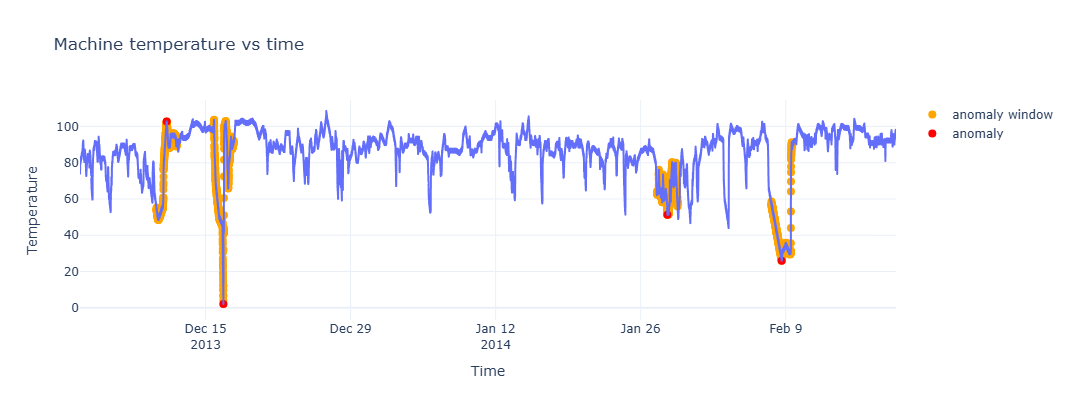

In [11]:
# Visualize line plot - temperature vs time
fig = px.line(df,
        x='time',
        y='value',
        width=1000,
        height=400,
        labels={'time': 'Time', 'value': 'Temperature'},
        template='plotly_white',
        title='Machine temperature vs time')

df_anomaly_points = df[df['anomaly_point'] == 1]
df_anomaly_windows = df[df['anomaly_window'] == 1]

fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                         y=df_anomaly_windows['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='anomaly window'
                        )
             )

fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                         y=df_anomaly_points['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='anomaly'
                        )
             )


fig.show()

# '''
# This is the matplotlib version for reporting
# plt.figure(figsize=(16, 4.5))
# plt.plot(df['time'], df['value'])
# plt.xlabel('Time')
# plt.ylabel('Temperature')
# plt.xticks(fontsize=8)
# plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=6))
# plt.grid(True)
# plt.title('Machine temperature over time')
# plt.show()
# '''

Visualize anomalies and windows in the plot
- It is obvious to visually know 2nd and 4th as anomaly point; 1st and 3rd are less straightforward
- Window covers points before and after anomalies. Might be a hint of detection

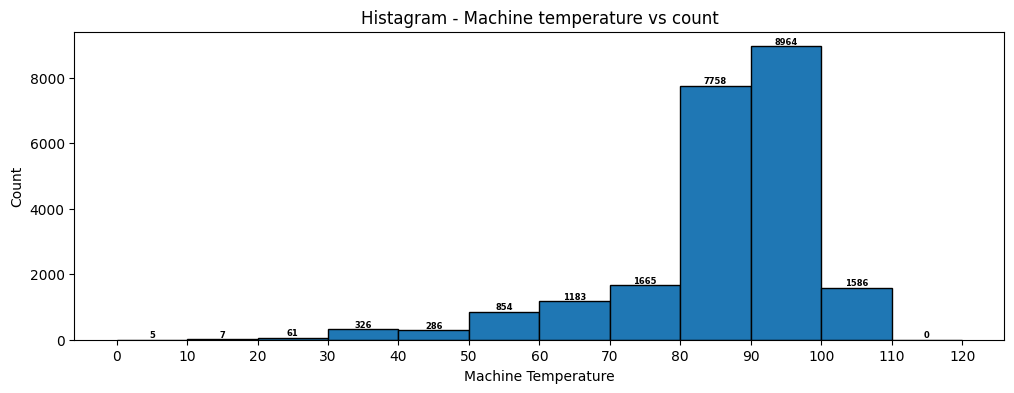

In [12]:
# Histagram
bin_size = range(0, 121, 10)
plt.figure(figsize=(12, 4))
value_count, baredge, bar = plt.hist(df['value'], bins=bin_size, edgecolor='black')

for c, edge, bar_ in zip(value_count, baredge, bar):
    plt.text(
        bar_.get_x() + bar_.get_width() / 2,
        bar_.get_height(),
        int(c),
        ha='center',
        va='bottom',
        fontsize=6,
        fontweight='bold',
        color='black',
    )
plt.xlabel('Machine Temperature')
plt.ylabel('Count')
plt.xticks(bin_size)
plt.title('Histagram - Machine temperature vs count')
plt.show()

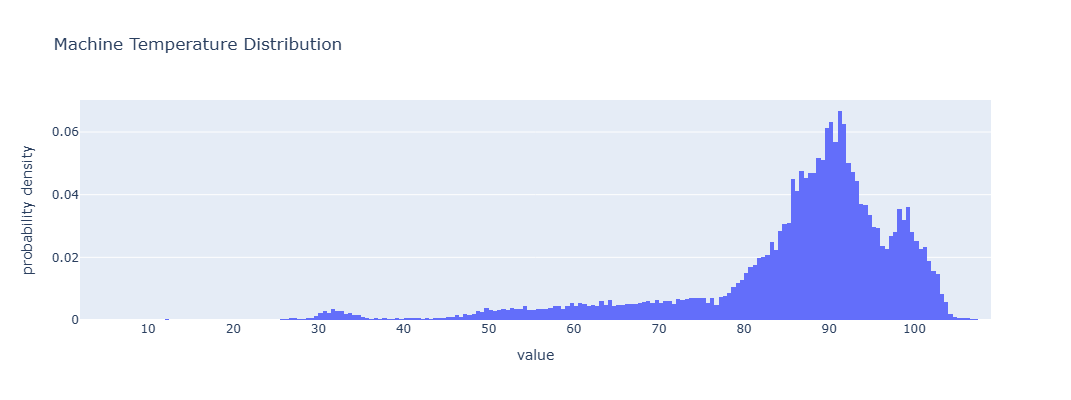

In [13]:
fig = px.histogram(df,
                   x='value', 
                   width=1000,
                   height=400,
                   histnorm="probability density",
                   title='Machine Temperature Distribution'
                  )
fig.update_xaxes(tickmode='array',
                 tickvals=list(range(0, 121, 10)),
                )
fig.show()

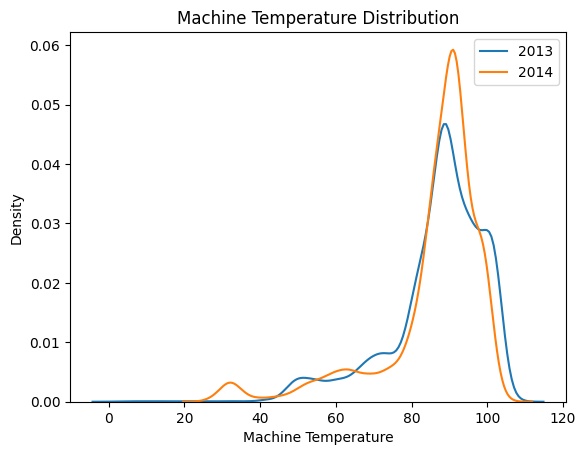

In [14]:
sns.kdeplot(df.loc[df['year']==2013, 'value'], label='2013')
sns.kdeplot(df.loc[df['year']==2014, 'value'], label='2014')

plt.xlabel('Machine Temperature')
plt.legend()
plt.title('Machine Temperature Distribution')
plt.show()

Majority of temperature is around 80~100 degree

### Anomaly Detection

#### ARIMA
#### Modeling
- [x] Split reasonable normal period for model training
- [x] Augmented Dickey Fuller to discover if it is stationary
  - If it is not stationary, differencing and log/ Box-cox transform is needed
  - Check ADF again for stationary
- [x] ARIMA model order selection (Require stationary data)
  - AR model order (p): Use partial autocorrelation to discover significant lags for past value
  - I model order (d): Use differencing checked before
  - MA model order (q): Use autocorrelation to discover significant lags for past forecast error

#### Anomaly detection
- [x] step 1: ARIMA model training with normal period
- [x] step 2: walk-forward one step forecasting on test-2
- [x] step 3: Anomaly detection with threshold

#### Modeling - splitting

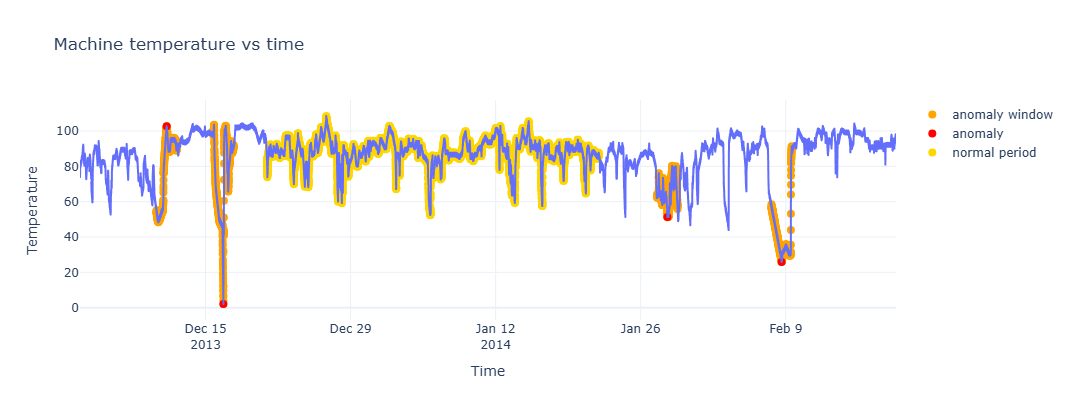

In [15]:
# Choose the normal period time stamp
'''
Guideline:
- Not including anomaly window
- Continuous period
- Value can be between 60~100. Judging the long term behavior, 60~100 is considered regular machine working range
- Period should be long enough (~40% of whole dataset)
'''
df_arima_normal = df[(df['time'] >= '2013-12-20 22:15:00') & (df['time'] <= '2014-01-21 22:50:00')]  # training period
df_arima_test_1 = df[df['time'] < '2013-12-20 22:15:00']  # Test period 1
df_arima_test_2 = df[df['time'] > '2014-01-21 22:50:00']  # Test period 2

fig = px.line(df,
        x='time',
        y='value',
        width=1000,
        height=400,
        labels={'time': 'Time', 'value': 'Temperature'},
        template='plotly_white',
        title='Machine temperature vs time')

fig.add_trace(go.Scatter(x=df_anomaly_windows['time'],
                         y=df_anomaly_windows['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='anomaly window'
                        )
             )

fig.add_trace(go.Scatter(x=df_anomaly_points['time'], 
                         y=df_anomaly_points['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='anomaly'
                        )
             )

fig.add_trace(go.Scatter(x=df_arima_normal['time'],
                         y=df_arima_normal['value'],
                         mode='markers',
                         marker=dict(size=8,color='gold',symbol='circle'),
                         name='normal period',
                        )
             )
fig.show()

#### Modeling - ADF (without differencing)

In [16]:
result = adfuller(df_arima_normal['value'], regression='c', autolag='AIC')
print('ADF w/o differencing')
print(f'ADF statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Used lags: {result[2]}')
print(f'Critical value: {result[4]}')

ADF w/o differencing
ADF statistics: -7.86846526219064
p-value: 5.059722036581667e-12
Used lags: 8
Critical value: {'1%': -3.4310589108224967, '5%': -2.861853293523464, '10%': -2.5669367610743086}


Without differencing, normal period is considered stationary (mean and std is constant over time)

#### Modeling - ARIMA model order selection (without differencing)

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\3157770454.py:19: UserWarning:

Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.



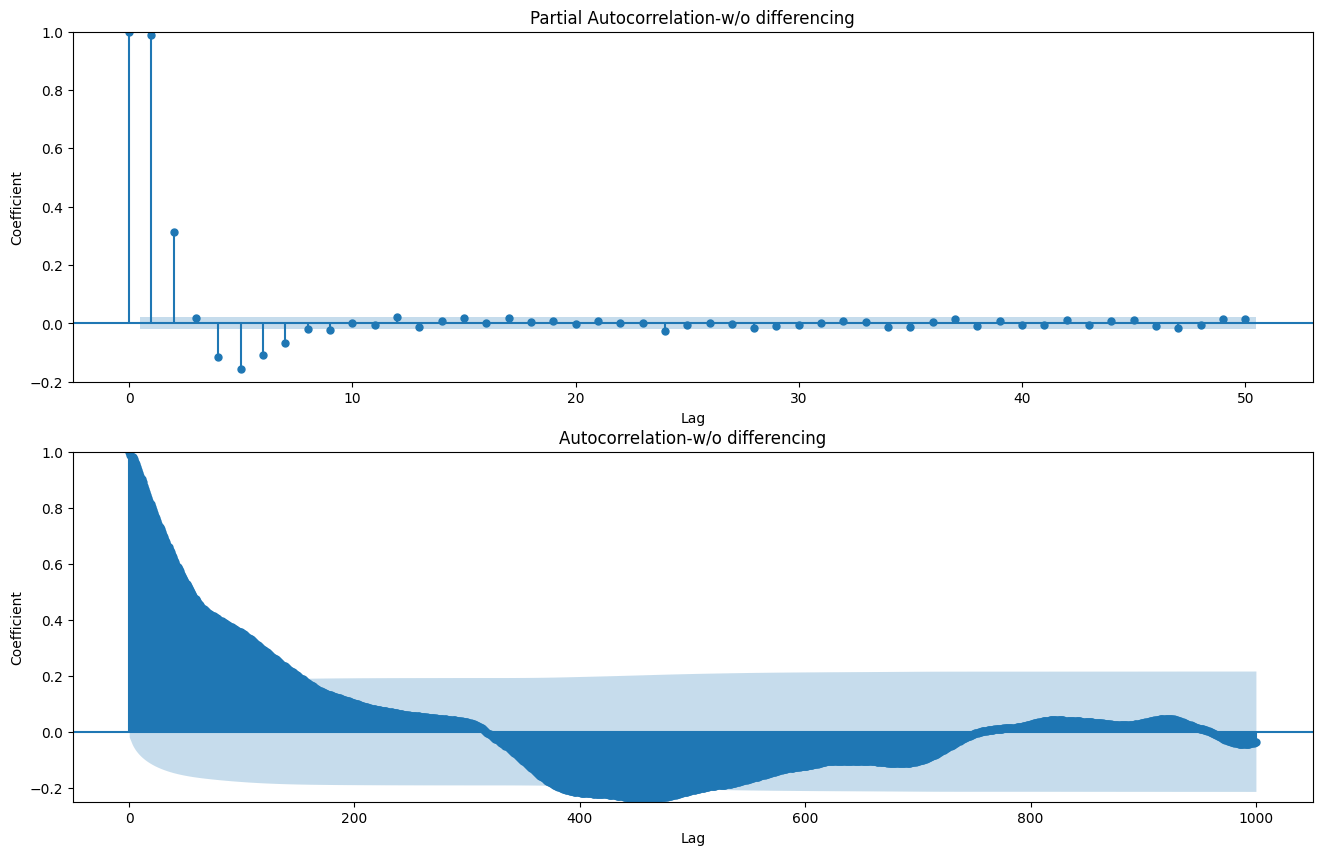

In [17]:
# Use partial autocorrelation for AR order (p)
# Integrated: p is 0 (no need for differencing)
# Use autocorrelation for MA order (q)

fig, ax = plt.subplots(2, 1, figsize=(16, 10))
plot_pacf(df_arima_normal['value'], lags=50, method='ywm', alpha=0.05, ax=ax[0])
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('Coefficient')
ax[0].set_ylim(-0.2,1)
ax[0].set_title('Partial Autocorrelation-w/o differencing')


plot_acf(df_arima_normal['value'], lags=1000, ax=ax[1])
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('Coefficient')
ax[1].set_ylim(-0.25,1)
ax[1].set_title('Autocorrelation-w/o differencing')

fig.show()

#### Modeling - ADF (with differencing)

In [18]:
# Play: Use differencing --> Observe mean brought to zero
df_arima_normal['value_diff'] = df_arima_normal['value'].diff()
fig = px.line(df_arima_normal,
              x='time', 
              y='value_diff', 
              title='Temperature-Differenced', 
              labels={'time': 'Time', 'value': 'Temperature'})
fig.show()

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\3850916452.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [19]:
df_arima_normal_only_order_selection = df_arima_normal.dropna(subset=['value_diff'], axis=0)
df_arima_normal_only_order_selection

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,value_diff
5197,2013-12-20 22:20:00,84.490317,2013-12-20 22:20:00,2013,12,20,22,20,0,0,0.792753
5198,2013-12-20 22:25:00,84.576088,2013-12-20 22:25:00,2013,12,20,22,25,0,0,0.085771
5199,2013-12-20 22:30:00,82.048447,2013-12-20 22:30:00,2013,12,20,22,30,0,0,-2.527641
5200,2013-12-20 22:35:00,82.691248,2013-12-20 22:35:00,2013,12,20,22,35,0,0,0.642801
5201,2013-12-20 22:40:00,80.948741,2013-12-20 22:40:00,2013,12,20,22,40,0,0,-1.742506
...,...,...,...,...,...,...,...,...,...,...,...
14427,2014-01-21 22:30:00,87.282637,2014-01-21 22:30:00,2014,1,21,22,30,0,0,0.619210
14428,2014-01-21 22:35:00,85.342301,2014-01-21 22:35:00,2014,1,21,22,35,0,0,-1.940336
14429,2014-01-21 22:40:00,87.609982,2014-01-21 22:40:00,2014,1,21,22,40,0,0,2.267681
14430,2014-01-21 22:45:00,86.172180,2014-01-21 22:45:00,2014,1,21,22,45,0,0,-1.437802


In [20]:
# Augmented Dickey Fuller for stantionary check
result = adfuller(df_arima_normal_only_order_selection['value_diff'], regression='c', autolag='AIC')
print('ADF w/ differencing')
print(f'ADF statistics: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Used lags: {result[2]}')
print(f'Critical value: {result[4]}')

ADF w/ differencing
ADF statistics: -22.902819085219818
p-value: 0.0
Used lags: 15
Critical value: {'1%': -3.43105952616764, '5%': -2.861853565434431, '10%': -2.566936905813735}


With differencing, normal period is considered stationary (mean and std is constant over time)

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\4216895353.py:15: UserWarning:

Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.



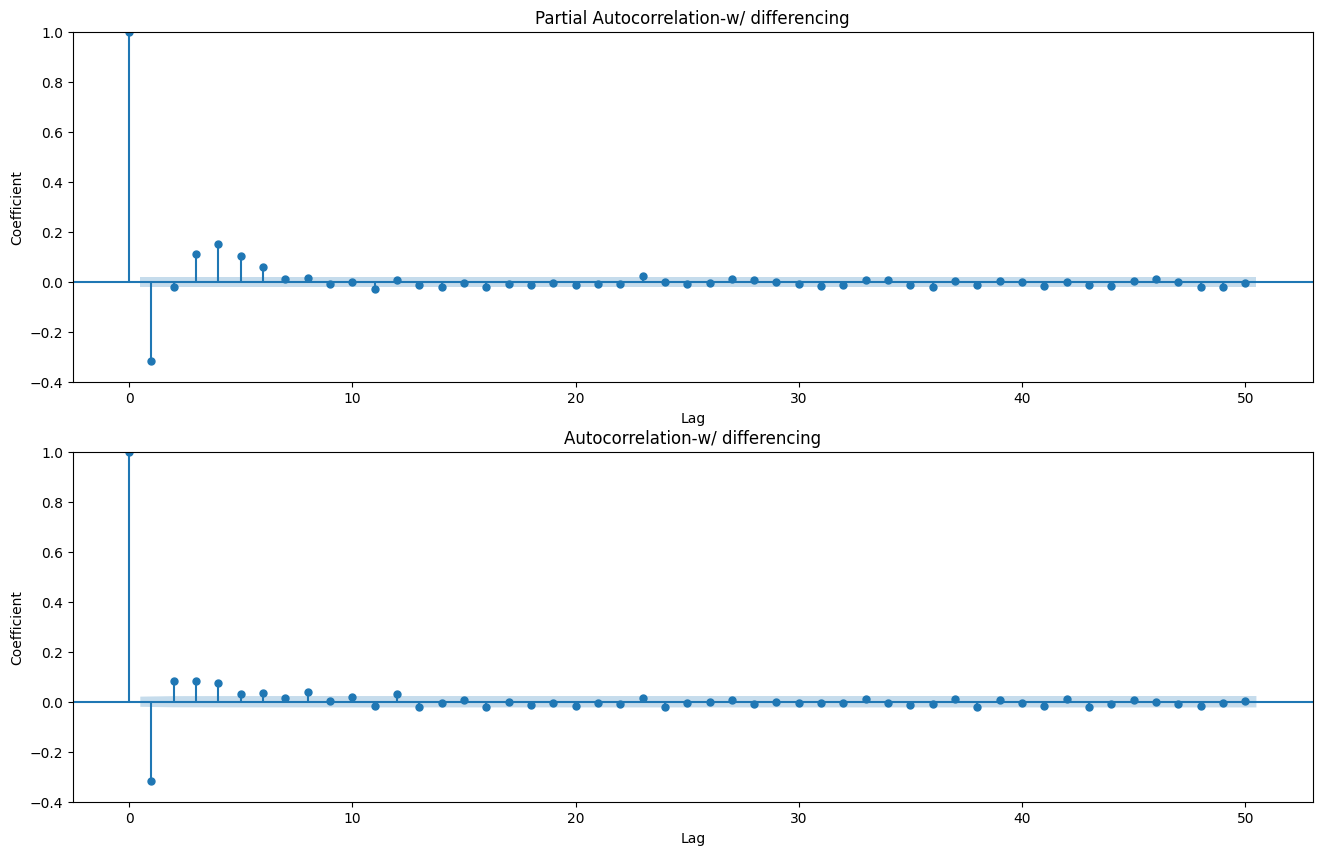

In [21]:
fig, ax = plt.subplots(2, 1, figsize=(16, 10))
plot_pacf(df_arima_normal_only_order_selection['value_diff'], lags=50, method='ywm', alpha=0.05, ax=ax[0])
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('Coefficient')
ax[0].set_ylim(-0.4,1)
ax[0].set_title('Partial Autocorrelation-w/ differencing')


plot_acf(df_arima_normal_only_order_selection['value_diff'], lags=50, ax=ax[1])
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('Coefficient')
ax[1].set_ylim(-0.4,1)
ax[1].set_title('Autocorrelation-w/ differencing')

fig.show()

Without differencing: PACF shows lag 1 to 9 exceeding blue zone, meaning they are significant to value forecasting with past values. Choose p=9.  
With differencing: PACF shows lag 1 to 6 are significant to value forecasting. Choose p=6

Without differencing: ACF sees a trend behavior till around 300 lags (25 hours lag)  
With differencing: Till lag 8 (except for lag 7) ACF shows significant on forecating. Choose q as 8.

Due to stationary without differencing, try ARIMA with order=(9, 0, 8)

Observation - order (8, 0, 9)
- Threshold 2.9 degree is too small for the machine temperature anomaly window
- The model seems overfitted. We need to choose another order

Order selection
- PACF: p is chosen as 1 or 2 at most (maybe 3)
- ACF: it is trending, meaning it is not stationary. We need differencing. d = 1 and q is 1 or 2 at most
- (1, 1, 1), (1, 1, 2), (2, 1, 1), (2, 1, 2)

In [22]:
# Find the best order combination
orders = [(1, 1, 1), (1, 1, 2), (1, 1, 3), (2, 1, 1), (2, 1, 2), (2, 1, 3), (9, 0, 8)]
for order in orders:
    arima_model = ARIMA(df_arima_normal['value'], order=order)
    res = arima_model.fit()
    print(f'The chosen order: {order}')
    print(f'AIC: {res.aic:.3f}')
    print(f'BIC: {res.bic:.3f}')
    print('========================')

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.



The chosen order: (1, 1, 1)
AIC: 26116.202
BIC: 26137.594


C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.



The chosen order: (1, 1, 2)
AIC: 25653.457
BIC: 25681.980


C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.



...

The chosen order: (2, 1, 2)
AIC: 25652.781
BIC: 25688.435


C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.



The chosen order: (2, 1, 3)
AIC: 25654.318
BIC: 25697.103


C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



The chosen order: (9, 0, 8)
AIC: 25613.602
BIC: 25749.088


Order(1 , 1, 2) has the lowest BIC. Indicating overfitting is penalized.

#### Anomaly detection - ARIMA model training
**ARIMA Condition order=(1, 1, 2)**

In [23]:
# ARIMA training
arima_model = ARIMA(df_arima_normal['value'], order=(1, 1, 2))
fitted_arima = arima_model.fit()

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.



In [24]:
# Get the ARIMA fitted value
df_arima_normal['Predicted value'] = fitted_arima.fittedvalues
df_arima_normal_threshold = df_arima_normal.iloc[1:]
df_arima_normal_threshold

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\4187461299.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,value_diff,Predicted value
5197,2013-12-20 22:20:00,84.490317,2013-12-20 22:20:00,2013,12,20,22,20,0,0,0.792753,83.697535
5198,2013-12-20 22:25:00,84.576088,2013-12-20 22:25:00,2013,12,20,22,25,0,0,0.085771,84.230688
5199,2013-12-20 22:30:00,82.048447,2013-12-20 22:30:00,2013,12,20,22,30,0,0,-2.527641,84.540755
5200,2013-12-20 22:35:00,82.691248,2013-12-20 22:35:00,2013,12,20,22,35,0,0,0.642801,82.977528
5201,2013-12-20 22:40:00,80.948741,2013-12-20 22:40:00,2013,12,20,22,40,0,0,-1.742506,82.523912
...,...,...,...,...,...,...,...,...,...,...,...,...
14427,2014-01-21 22:30:00,87.282637,2014-01-21 22:30:00,2014,1,21,22,30,0,0,0.619210,86.397966
14428,2014-01-21 22:35:00,85.342301,2014-01-21 22:35:00,2014,1,21,22,35,0,0,-1.940336,86.964307
14429,2014-01-21 22:40:00,87.609982,2014-01-21 22:40:00,2014,1,21,22,40,0,0,2.267681,86.060103
14430,2014-01-21 22:45:00,86.172180,2014-01-21 22:45:00,2014,1,21,22,45,0,0,-1.437802,86.920785


In [25]:
# Get the residual mean and std for threshold
df_arima_normal_threshold['Residual'] = df_arima_normal_threshold['value'] - df_arima_normal_threshold['Predicted value']
resid_mean = df_arima_normal_threshold['Residual'].mean()
resid_std = df_arima_normal_threshold['Residual'].std()
threshold_resid = resid_mean + 3 * resid_std
print(f'Residual mean at normal period: {resid_mean}')
print(f'Residual std at normal period: {resid_std}')
print(f'Threshold of residual: {threshold_resid}')

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\955907390.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Residual mean at normal period: 0.0004117117888714226
Residual std at normal period: 0.9700731638139137
Threshold of residual: 2.9106312032306128


In [26]:
# Visualize actual and predicted value at normal
fig = go.Figure()

fig.add_trace(go.Scatter(x=df_arima_normal_threshold['time'],
                         y=df_arima_normal_threshold['value'],
                         name='Actual',
                        )
             )
fig.add_trace(go.Scatter(x=df_arima_normal_threshold['time'],
                         y=df_arima_normal_threshold['Predicted value'],
                         name='Predicted'
                        )
             )

fig.update_layout(template='simple_white',
                  font=dict(size=14),
                  xaxis_title='Time',
                  yaxis_title='Temperature',
                  width=1200,
                  height=400,
                  title='Normal period - Actual vs Predicted')
fig.show()

#### Anoamly detection - Walk forward one-step forecasting on test-2

In [27]:
# To resolve the memory gap issue, concatenate a few rows from normal period
df_arima_normal_concat = df_arima_normal_threshold.iloc[-5:][['timestamp', 'value', 'time', 'year', 'month', 'day', 'hour', 'minute', 'anomaly_point', 'anomaly_window']] 
df_arima_test_2_pred = pd.concat([df_arima_normal_concat, df_arima_test_2])
df_arima_test_2_pred.head(10)

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
14427,2014-01-21 22:30:00,87.282637,2014-01-21 22:30:00,2014,1,21,22,30,0,0
14428,2014-01-21 22:35:00,85.342301,2014-01-21 22:35:00,2014,1,21,22,35,0,0
14429,2014-01-21 22:40:00,87.609982,2014-01-21 22:40:00,2014,1,21,22,40,0,0
14430,2014-01-21 22:45:00,86.172180,2014-01-21 22:45:00,2014,1,21,22,45,0,0
14431,2014-01-21 22:50:00,87.752851,2014-01-21 22:50:00,2014,1,21,22,50,0,0
14432,2014-01-21 22:55:00,86.369914,2014-01-21 22:55:00,2014,1,21,22,55,0,0
14433,2014-01-21 23:00:00,87.219846,2014-01-21 23:00:00,2014,1,21,23,0,0,0
14434,2014-01-21 23:05:00,85.774283,2014-01-21 23:05:00,2014,1,21,23,5,0,0
14435,2014-01-21 23:10:00,86.477555,2014-01-21 23:10:00,2014,1,21,23,10,0,0
14436,2014-01-21 23:15:00,85.715521,2014-01-21 23:15:00,2014,1,21,23,15,0,0


In [28]:
df_arima_test_2

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window
14432,2014-01-21 22:55:00,86.369914,2014-01-21 22:55:00,2014,1,21,22,55,0,0
14433,2014-01-21 23:00:00,87.219846,2014-01-21 23:00:00,2014,1,21,23,0,0,0
14434,2014-01-21 23:05:00,85.774283,2014-01-21 23:05:00,2014,1,21,23,5,0,0
14435,2014-01-21 23:10:00,86.477555,2014-01-21 23:10:00,2014,1,21,23,10,0,0
14436,2014-01-21 23:15:00,85.715521,2014-01-21 23:15:00,2014,1,21,23,15,0,0
...,...,...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5,0,0
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10,0,0
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15,0,0
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20,0,0


In [29]:
# Use walk forward one step forecasting
res_test = fitted_arima.apply(df_arima_test_2_pred['value'])
pred = res_test.get_prediction(dynamic=False)
df_arima_test_2['Predicted value'] = pred.predicted_mean  # Return predicted value
df_arima_test_2['Residual'] = df_arima_test_2['value'] - df_arima_test_2['Predicted value']
df_arima_test_2
# # The following is too slow
# test2_pred = []
# pred2_arima_no_diff = fitted_arima_no_diff
# counter = 0
# for y_test in df_arima_test_2['value']:
#     y_pred = pred2_arima_no_diff.forecast(1).iloc[0]
#     test2_pred.append(y_pred)
#     pred2_arima_no_diff = pred2_arima_no_diff.append([y_test], refit=False)  # Update ARIMA with the latest point
#     counter += 1
#     print(f'This is {counter}th run')

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning:

An unsupported index was provided and will be ignored when e.g. forecasting.

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\2113110809.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\nanya\AppData\Local\Temp\ipykernel_10172\2113110809.py:5: SettingWithCopyWarning:


A value is trying to be s

,timestamp,value,time,year,month,day,hour,minute,anomaly_point,anomaly_window,Predicted value,Residual
14432,2014-01-21 22:55:00,86.369914,2014-01-21 22:55:00,2014,1,21,22,55,0,0,87.277024,-0.907110
14433,2014-01-21 23:00:00,87.219846,2014-01-21 23:00:00,2014,1,21,23,0,0,0,86.836248,0.383598
14434,2014-01-21 23:05:00,85.774283,2014-01-21 23:05:00,2014,1,21,23,5,0,0,87.068685,-1.294402
14435,2014-01-21 23:10:00,86.477555,2014-01-21 23:10:00,2014,1,21,23,10,0,0,86.291975,0.185580
14436,2014-01-21 23:15:00,85.715521,2014-01-21 23:15:00,2014,1,21,23,15,0,0,86.273148,-0.557627
...,...,...,...,...,...,...,...,...,...,...,...,...
22690,2014-02-19 15:05:00,98.185415,2014-02-19 15:05:00,2014,2,19,15,5,0,0,97.738861,0.446553
22691,2014-02-19 15:10:00,97.804168,2014-02-19 15:10:00,2014,2,19,15,10,0,0,98.058733,-0.254565
22692,2014-02-19 15:15:00,97.135468,2014-02-19 15:15:00,2014,2,19,15,15,0,0,97.984707,-0.849239
22693,2014-02-19 15:20:00,98.056852,2014-02-19 15:20:00,2014,2,19,15,20,0,0,97.481461,0.575391


#### Anomaly detection - Anomaly detection with threshold

In [30]:
df_arima_test_2_anomaly_detected = df_arima_test_2[df_arima_test_2['Residual'].abs() >= threshold_resid]
df_arima_test_2_anomaly = df_arima_test_2[df_arima_test_2['anomaly_point'] == 1]

fig = go.Figure()

fig.add_trace(go.Scatter(x=df_arima_test_2['time'],
                         y=df_arima_test_2['value'],
                         name='Actual',
                        )
             )

fig.add_trace(go.Scatter(x=df_arima_test_2['time'],
                         y=df_arima_test_2['Predicted value'],
                         name='Predicted'
                        )
             )

fig.add_trace(go.Scatter(x=df_arima_test_2_anomaly_detected['time'],
                         y=df_arima_test_2_anomaly_detected['value'],
                         mode='markers',
                         marker=dict(size=8,color='orange',symbol='circle'),
                         name='Anomaly detected'
                        )
             )

fig.add_trace(go.Scatter(x=df_arima_test_2_anomaly['time'], 
                         y=df_arima_test_2_anomaly['value'],
                         mode='markers',
                         marker=dict(size=8,color='red',symbol='circle'),
                         name='True anomaly'
                        )
             )

fig.update_layout(template='simple_white',
                  font=dict(size=14),
                  xaxis_title='Time',
                  yaxis_title='Temperature',
                  width=1200,
                  height=400,
                  title='Test_2 - Actual vs Predicted')
fig.show()

#### Anomaly detection - Conclusion
- ARIMA model order (1, 1, 2). Order is determined by BIC value
- Threshold (2.91) is calculated by normal period with fitted ARIMA value
- To prevent memory gap issue (first data point is not forecasted due to 1 level diferecning), concatenate a few rows to test period for one step ahead forecating
- Flagged anomalies do not match well with truth anomalies
- ARIMA does not work as expected because
  - ARIMA assumes forecasting is linear relationship but reality is not
  - ARIMA forecasting on test period follows too well on actual value. Even at the point of anomaly timestamp, the residual remains small, making it not flagged. 